### UPSC Essay Evaluation system using llms

1 - (start ) - 

2.[clearity of thoughts(cot)
Deep of analysis(DOA)
Language]

3 - (final evaluation)
4 - (end)


state - 
essay - text
cot_feedback - text
doa_feedback - text
lang_feedback - text
final_feedback - text
individual_score- []
avg_score _ float

In [16]:
import sys
print(sys.executable)

/home/sarveshp/Desktop/AgenticAI_Langchain-Langgraph_X-main/AgenticAI_Langchain-Langgraph_X-main/venv/bin/python


In [17]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI         # ← changed
from typing import TypedDict
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field

import operator

load_dotenv()

True

In [18]:
model = ChatOpenAI(model="gpt-4o-mini") # gpt 4.o all model is giving structured outputs

In [19]:
## this is the json schema for the evaluation output which we create so that i can get the structured output from the model and then use it for further processing

class evaluationSchema(BaseModel):
    
    feedback: str = Field(description="Detailed feedback for the essay")
    score: int = Field(description="Score for the essay on a scale of 1 to 10", ge=1, le=10)

In [20]:
structured_model = model.with_structured_output(evaluationSchema)

In [21]:
essay = """
Artificial Intelligence (AI) is transforming the way we live and work in today’s world.
It helps automate repetitive tasks, saving time and increasing efficiency. 
In industries like healthcare, AI assists doctors in diagnosing diseases more accurately. 
In education, it enables personalized learning experiences for students. 
Businesses use AI for data analysis, customer support, and decision-making. 
It also powers technologies like self-driving cars and smart assistants. 
AI improves productivity and reduces human error in many fields. 
However, it also raises concerns about job displacement and data privacy. 
Responsible use of AI is essential to balance its benefits and risks. 
Overall, AI plays a crucial role in shaping the future of society."""

In [22]:
prompt = f""" evaluate the language quality of this essay and provide feedback and a score out of 10 for the essay: {essay}"""
structured_model.invoke(prompt)

evaluationSchema(feedback='The essay presents a clear and concise overview of the role of Artificial Intelligence (AI) in modern life, highlighting both its benefits and concerns. However, the writing could be improved with greater variety in sentence structure and more elaboration on key points. For instance, examples of specific AI applications could be expanded to enhance understanding. Additionally, while the concluding sentence effectively summarizes the sentiment about AI, it could benefit from a more assertive or nuanced perspective on the future implications. Overall, the language is functional and direct, but it lacks deeper engagement or complexity in expression.', score=7)

In [23]:
class UPSCState(TypedDict):
    essay: str
    language_quality_feedback: str
    analysis_feedback: str
    clarity_of_thought_feedback: str
    overall_feedback: str
    individual_scores:Annotated[list[int], operator.add]
    average_score: float


In [24]:
def evaluate_language_quality(state: UPSCState) -> UPSCState:
    prompt = f""" evaluate the language quality of this essay and provide feedback and a score out of 10 for the essay: {state['essay']}"""
    output = structured_model.invoke(prompt)


    return {'language_quality_feedback': output.feedback, 'individual_scores': [output.score]}

In [25]:
def evaluate_analysis(state: UPSCState) -> UPSCState:
    prompt = f""" Evaluate the depth and quality of the following analysis in this essay and provide feedback and a score out of 10 for the essay: {state['essay']}"""
    output = structured_model.invoke(prompt)


    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

In [26]:
def evaluate_clarity_of_thought(state: UPSCState) -> UPSCState:
    prompt = f""" Evaluate the clarity of thought in this essay and provide feedback and a score out of 10 for the essay: {state['essay']}"""
    output = structured_model.invoke(prompt)


    return {'clarity_of_thought_feedback': output.feedback, 'individual_scores': [output.score]}

In [29]:
def final_evaluation(state: UPSCState) -> UPSCState:
    ## summary feedback and final score
    prompt = f"""Based on the following feedbacks create a summarized feedback \n language feedback - {state['language_quality_feedback']} \n depth of analysis feedback - {state['analysis_feedback']} \n clarity of thought feedback - {state['clarity_of_thought_feedback']} \n Evaluate the overall quality of this essay and provide feedback and a score out of 10 for the essay: {state['essay']}""" 
    overall_feedback = model.invoke(prompt).content

    ## avg score
    average_score = sum(state['individual_scores']) / len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'average_score': average_score}


In [31]:
graph = StateGraph(UPSCState)

# add the nodes to the graph
graph.add_node('evaluate_language_quality', evaluate_language_quality)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_clarity_of_thought', evaluate_clarity_of_thought)
graph.add_node('final_evaluation', final_evaluation)


## add edges to the graph



graph.add_edge(START, 'evaluate_language_quality')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_clarity_of_thought')


graph.add_edge('evaluate_language_quality', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_clarity_of_thought', 'final_evaluation')
graph.add_edge('final_evaluation', END)


## compile  the graph 

workflow = compiled_graph = graph.compile()

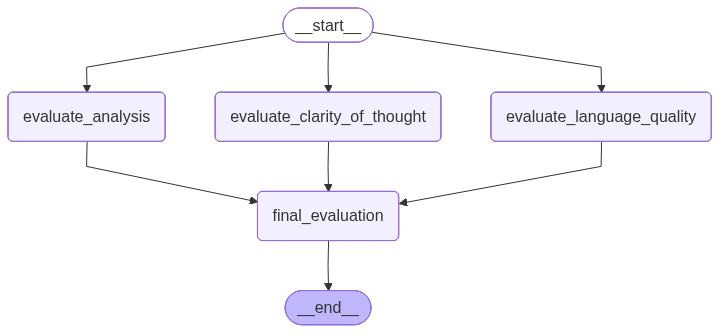

In [33]:
workflow

In [34]:
initial_state = {
    'essay': essay
}

final_state = workflow.invoke(initial_state)

In [35]:
final_state

{'essay': '\nArtificial Intelligence (AI) is transforming the way we live and work in today’s world.\nIt helps automate repetitive tasks, saving time and increasing efficiency. \nIn industries like healthcare, AI assists doctors in diagnosing diseases more accurately. \nIn education, it enables personalized learning experiences for students. \nBusinesses use AI for data analysis, customer support, and decision-making. \nIt also powers technologies like self-driving cars and smart assistants. \nAI improves productivity and reduces human error in many fields. \nHowever, it also raises concerns about job displacement and data privacy. \nResponsible use of AI is essential to balance its benefits and risks. \nOverall, AI plays a crucial role in shaping the future of society.',
 'language_quality_feedback': 'The essay presents a clear and concise overview of the impact of artificial intelligence on various aspects of life and work. It effectively lists the benefits of AI, such as improving e

In [36]:
essay2 = """Education is very important in life. Everyone should get education because it is good. Education helps people to learn things and become successful. Without education, people cannot do anything properly.

In today’s world, education is needed everywhere. People go to school and college to study and get jobs. Education also makes people smart and intelligent. It is useful for the country also.

In conclusion, education is very important and everyone should study hard to become successful in life."""

In [37]:
initial_state = {
    'essay': essay2
}

final_state = workflow.invoke(initial_state)

final_state

{'essay': 'Education is very important in life. Everyone should get education because it is good. Education helps people to learn things and become successful. Without education, people cannot do anything properly.\n\nIn today’s world, education is needed everywhere. People go to school and college to study and get jobs. Education also makes people smart and intelligent. It is useful for the country also.\n\nIn conclusion, education is very important and everyone should study hard to become successful in life.',
 'language_quality_feedback': "The essay presents a clear argument for the importance of education, which is a widely accepted perspective. However, it lacks depth and nuance in its discussion. The sentences are very simplistic and repetitive, which does not enhance the overall quality of the writing. For instance, the ideas could be expanded upon with examples or details that illustrate the benefits of education rather than just stating that it is 'good' or 'useful for the cou